## Stochastic Tree Models and stacked models with Boosting 

In [236]:
import pandas as pd
import pickle 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier
import shap

d = './raw_data/'

In [237]:
with open(r'C:\Users\divya\OneDrive\Documents\GitHub\spring-2025-greenlight\processed_data\analysis_build.pkl', 'rb') as filename:  
    df = pickle.load(filename)

conditions = [
    (df['wroi'] < 1),
    (df['wroi'] < 2),
    (df['wroi'] < 3),
    (df['wroi'] < 6),
    (df['wroi'] >= 6)
]
values = ['Flop', 'Break Even', 'Modest Hit', 'Hit', 'Blockbuster']
df['success_category'] = np.select(conditions, values, default='Unknown')

In [238]:
print(df.describe())

             budget  worldwide_boxoffice  domestic_boxoffice         year  \
count  4.272000e+03         4.272000e+03        4.272000e+03  4272.000000   
mean   3.907858e+07         1.130256e+08        5.113450e+07  2006.604167   
std    4.486176e+07         1.960773e+08        7.453157e+07     7.822660   
min    6.000000e+03         3.000000e+01        0.000000e+00  1990.000000   
25%    1.000000e+07         1.028531e+07        6.569525e+06  2001.000000   
50%    2.500000e+07         4.247993e+07        2.641999e+07  2007.000000   
75%    5.000000e+07         1.266739e+08        6.342375e+07  2013.000000   
max    4.000000e+08         2.748243e+09        9.366622e+08  2020.000000   

            rating      runtime  boxoffice_corrected     is_drama  \
count  4272.000000  4272.000000          4272.000000  4272.000000   
mean      6.355186   107.284878             0.014279     0.466760   
std       0.827319    17.903212             0.118653     0.498952   
min       1.900000    60.00000

### Visualization of Features

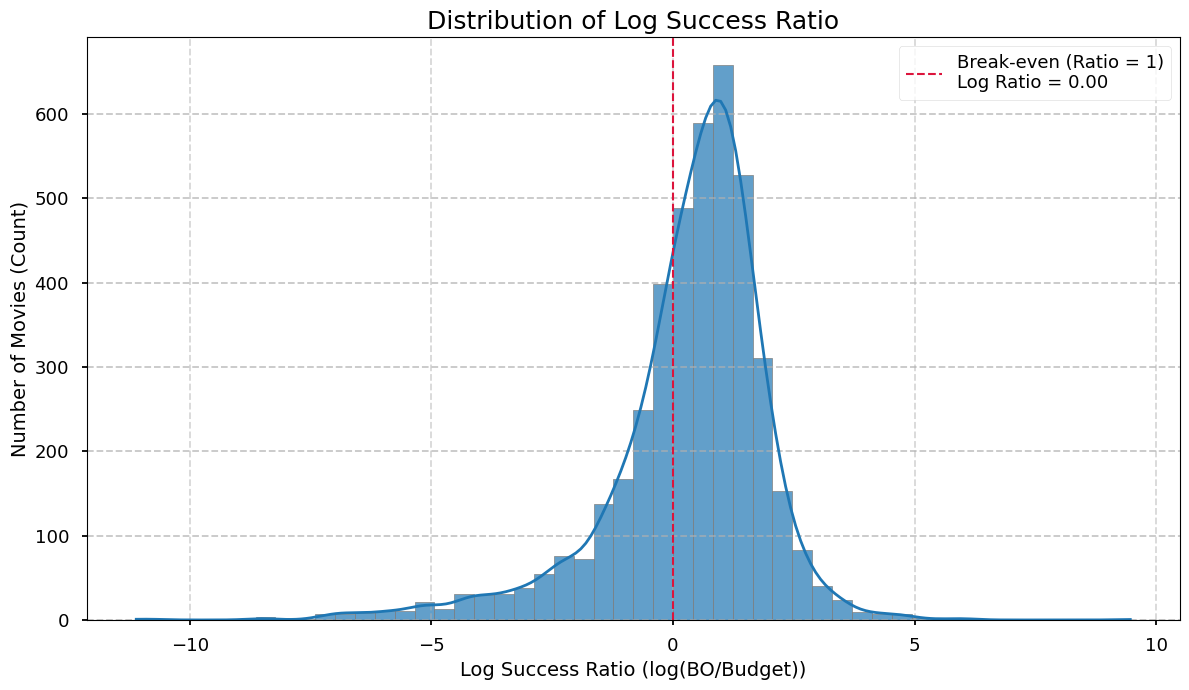

In [239]:
df['success_ratio'] = np.log((df['adjusted_worldwide_boxoffice'] / df['adjusted_budget']))

plt.style.use('seaborn-v0_8-talk') 

plt.figure(figsize=(12, 7)) 
sns.histplot(data=df, x='success_ratio', bins=50, kde=True,
             edgecolor='grey', linewidth=0.5, alpha=0.7,
             line_kws={'linewidth': 2}) 


plt.title('Distribution of Log Success Ratio', fontsize=18)
plt.xlabel('Log Success Ratio (log(BO/Budget))', fontsize=14)
plt.ylabel('Number of Movies (Count)', fontsize=14)
plt.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Break-even (Ratio = 1)\nLog Ratio = {0:.2f}')

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

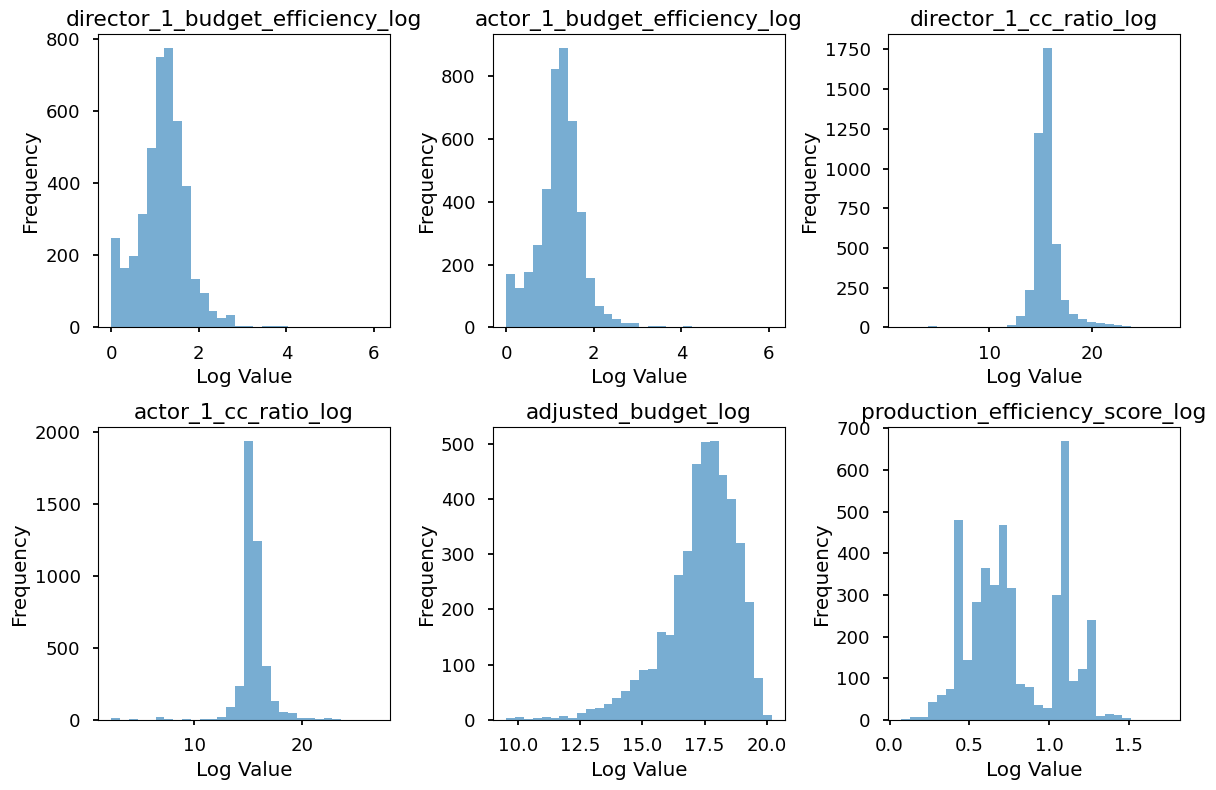

In [240]:
features = ['director_1_budget_efficiency',
            'actor_1_budget_efficiency',
            'director_1_cc_ratio',
            'actor_1_cc_ratio',
            'adjusted_budget',
            'production_efficiency_score']

for feature in features:
    df[f"{feature}_log"] = np.log1p(df[feature])

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    data = df[f"{feature}_log"].replace([np.inf, -np.inf], np.nan).dropna()
    axes[i].hist(data, bins=30, alpha=0.6)
    axes[i].set_title(f"{feature}_log")
    axes[i].set_xlabel("Log Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


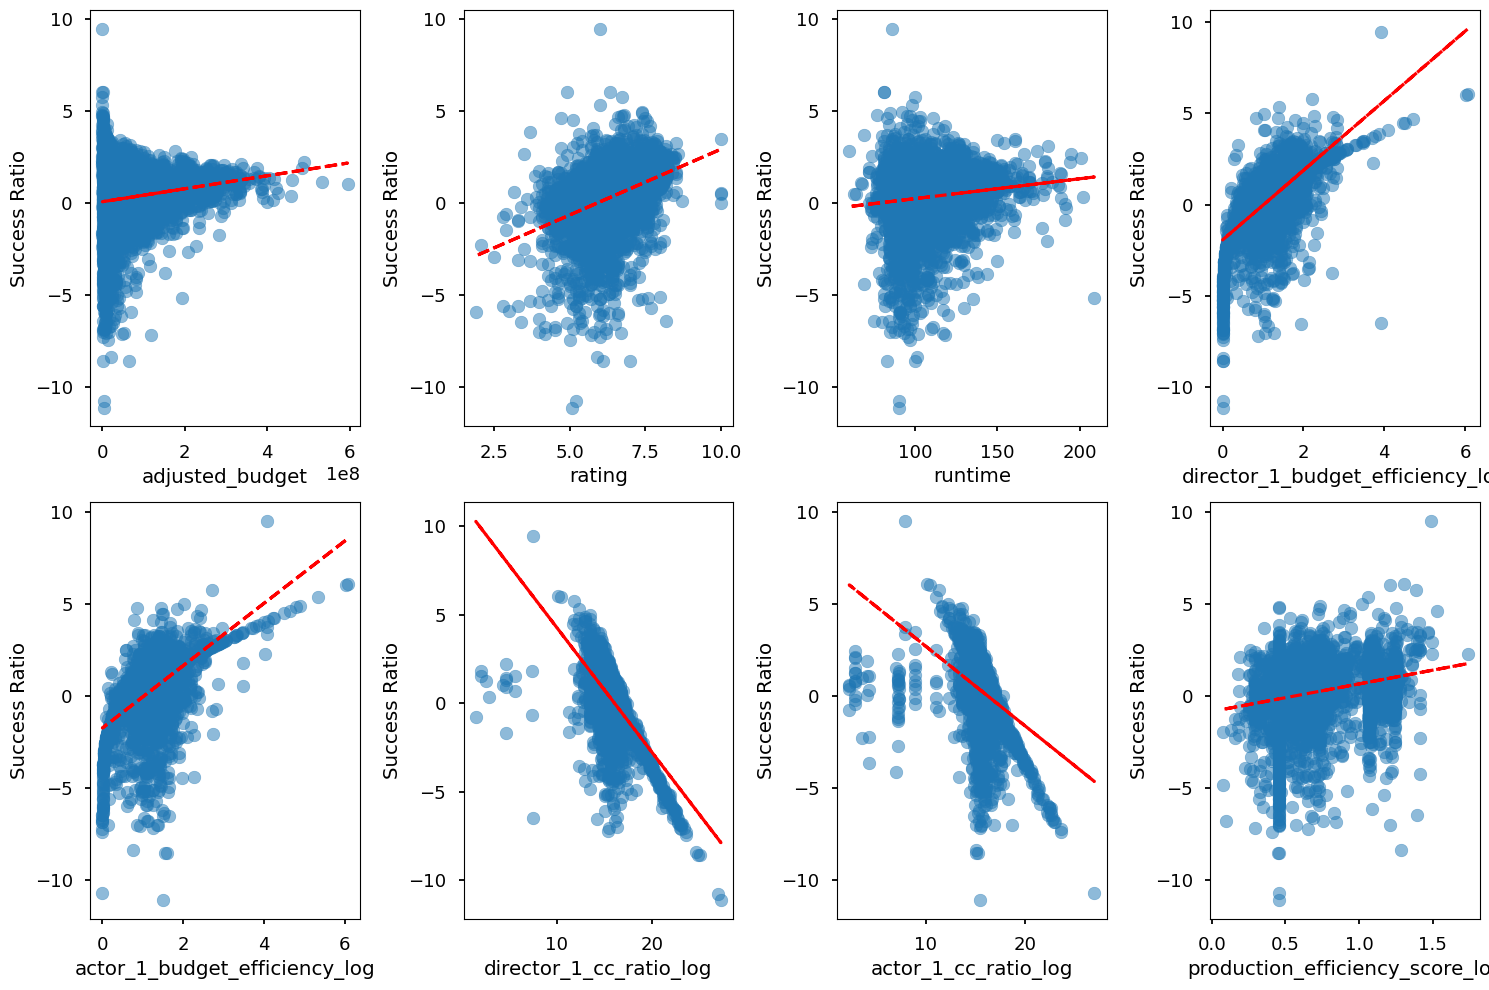

In [241]:
features = ['adjusted_budget', 'rating', 'runtime', 
            'director_1_budget_efficiency_log', 'actor_1_budget_efficiency_log',
            'director_1_cc_ratio_log', 'actor_1_cc_ratio_log','production_efficiency_score_log']

fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten() 

for i, feature in enumerate(features):
    ax = axes[i]
    
    df_clean = df.dropna(subset=[feature, 'success_ratio'])
    df_clean = df_clean[
        np.isfinite(df_clean[feature]) & 
        np.isfinite(df_clean['success_ratio'])
    ]
    
    x = df_clean[feature]
    y = df_clean['success_ratio']
    ax.scatter(x, y, alpha=0.5)
    ax.set_xlabel(feature)
    ax.set_ylabel('Success Ratio')
    
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--")

if len(features) < len(axes):
    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

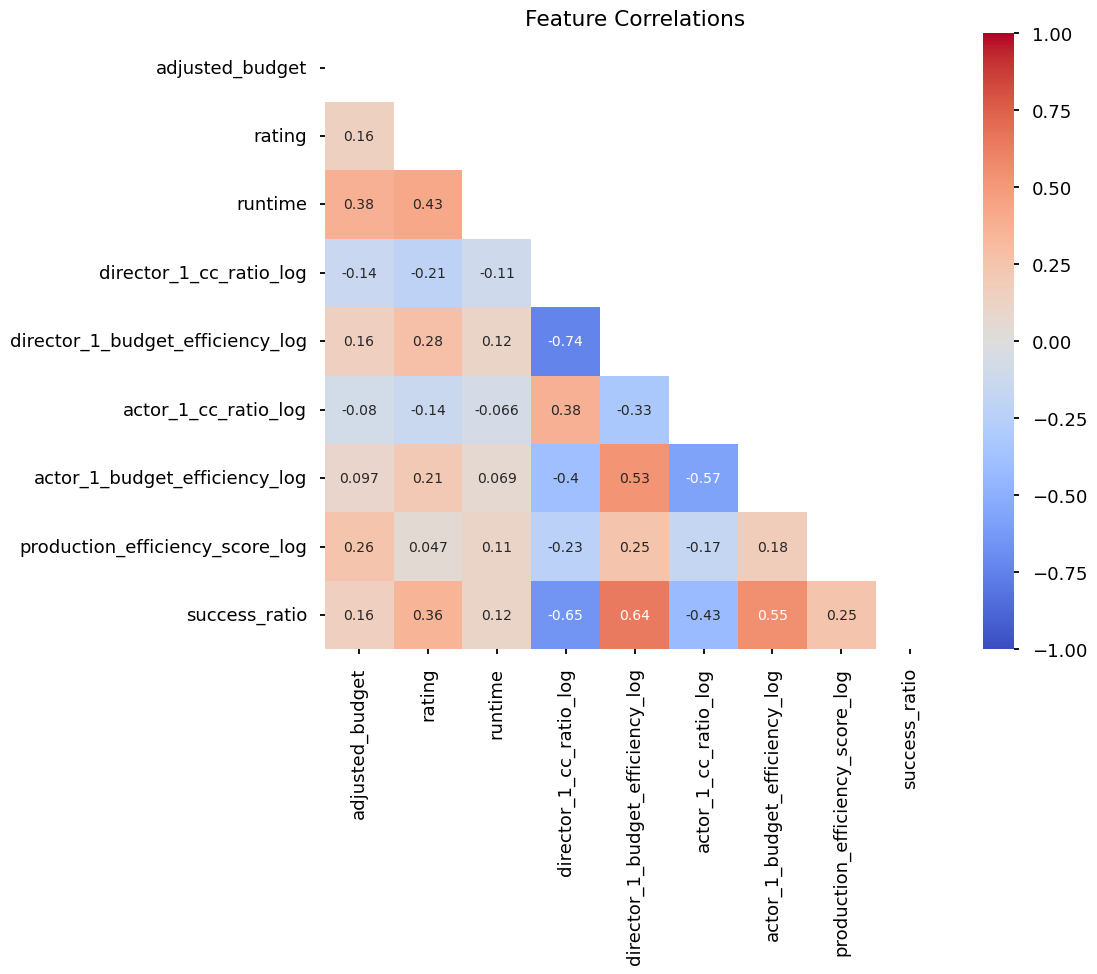

In [242]:
numeric_features = ['adjusted_budget', 'rating', 'runtime', 
                   'director_1_cc_ratio_log', 'director_1_budget_efficiency_log',
                   'actor_1_cc_ratio_log', 'actor_1_budget_efficiency_log','production_efficiency_score_log']

plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_features + ['success_ratio']].corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlations')
plt.show()

### Data Splitting for regression and classifcation Models

Missing values per feature:
Series([], dtype: int64)
Total missing values: 0


<Figure size 1200x800 with 0 Axes>

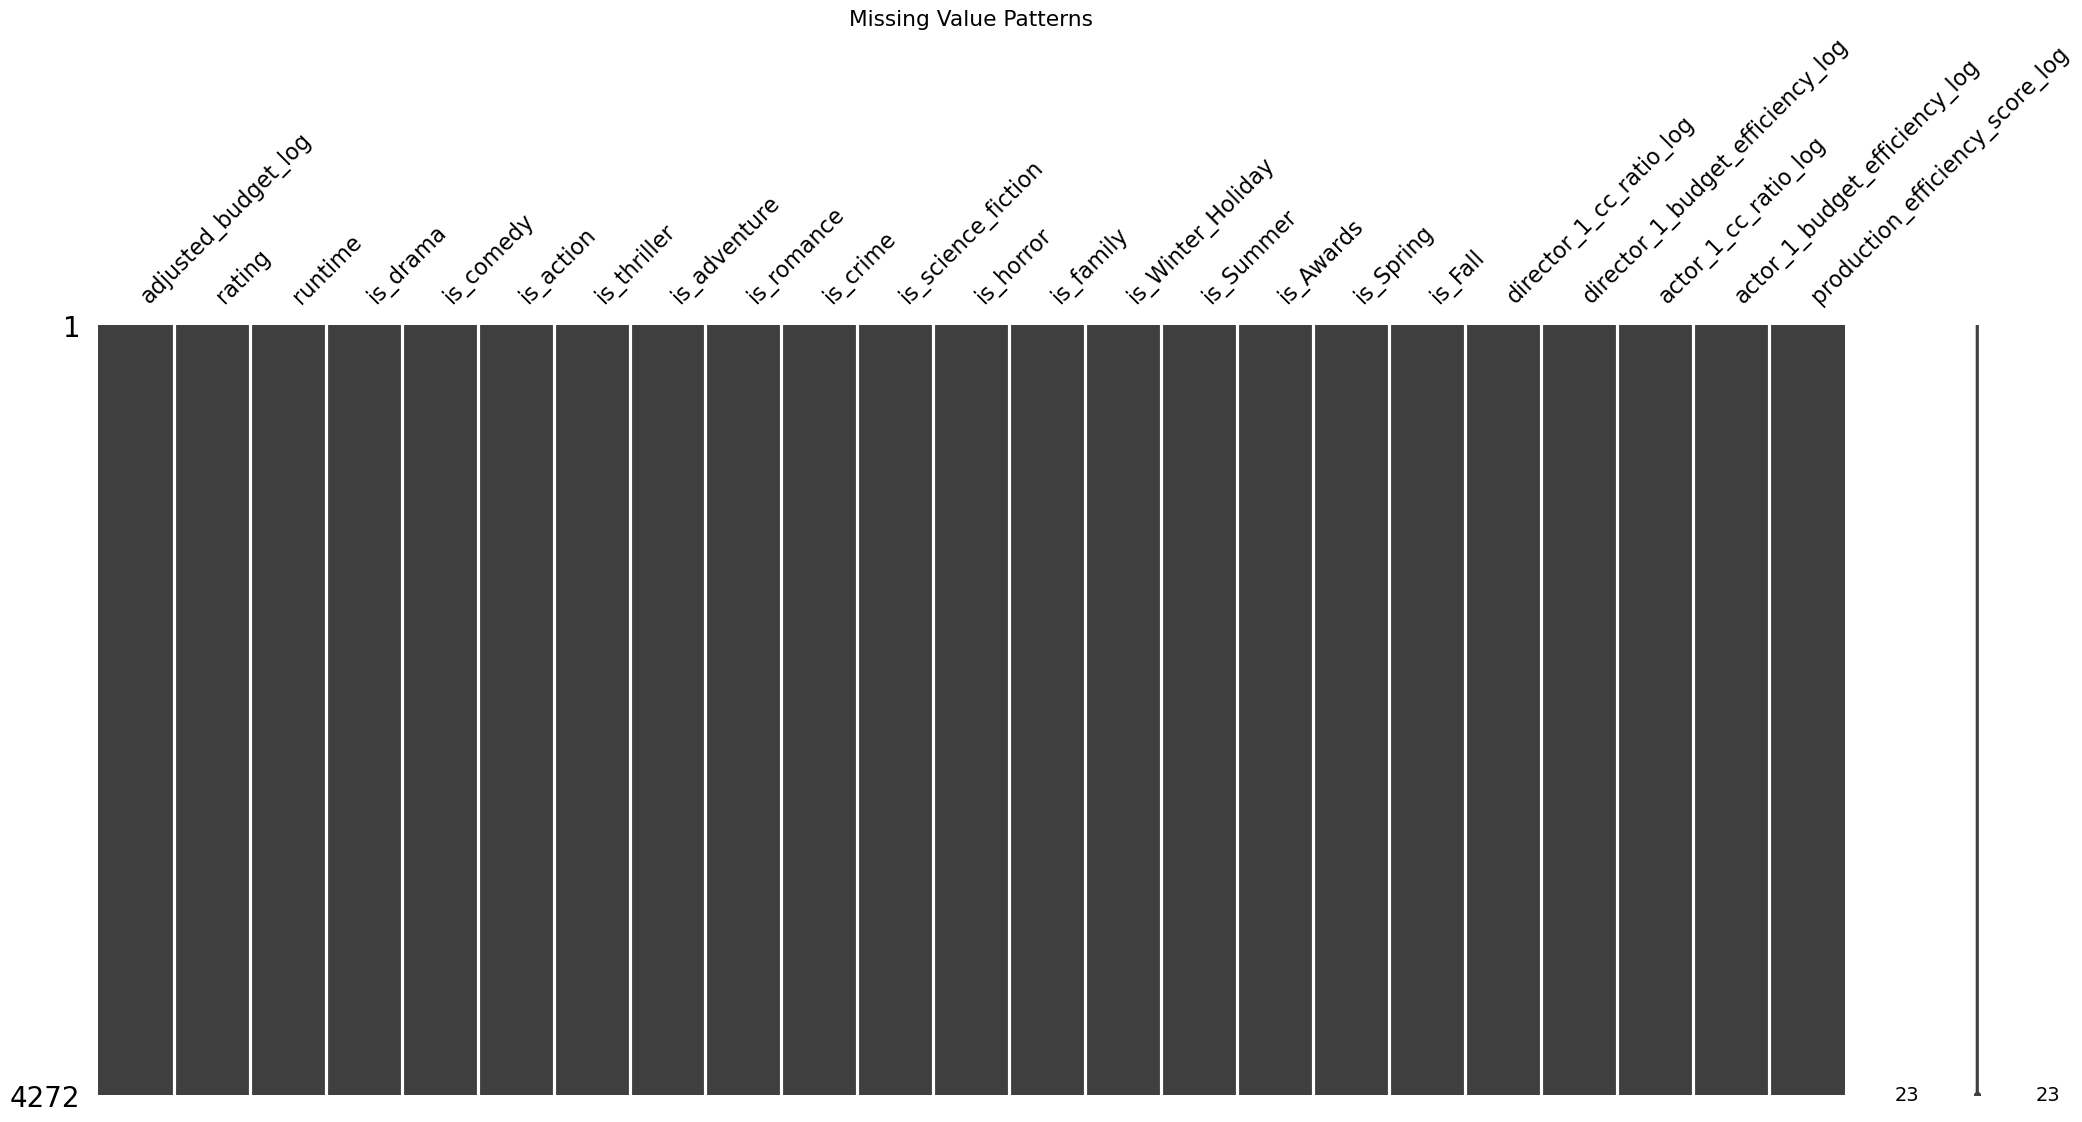

In [243]:
# Examine missing values
missing_values = X.isnull().sum()
print("Missing values per feature:")
print(missing_values[missing_values > 0])
print(f"Total missing values: {X.isnull().sum().sum()}")

# Visualize missing value patterns
import missingno as msno
plt.figure(figsize=(12, 8))
msno.matrix(X)
plt.title('Missing Value Patterns')
plt.show()

In [244]:
from sklearn.impute import SimpleImputer, KNNImputer
cols_to_impute = [
    'director_1_cc_ratio_log',
    'director_1_budget_efficiency_log',
    'actor_1_cc_ratio_log',
    'actor_1_budget_efficiency_log'
]

knn_imputer = KNNImputer(n_neighbors=5)
df[cols_to_impute] = knn_imputer.fit_transform(df[cols_to_impute])

In [245]:
features = ['adjusted_budget_log', 'rating', 'runtime', 
           'is_drama', 'is_comedy', 'is_action', 'is_thriller', 
           'is_adventure', 'is_romance', 'is_crime', 'is_science_fiction', 
           'is_horror', 'is_family', 'is_Winter_Holiday', 'is_Summer', 
           'is_Awards', 'is_Spring', 'is_Fall', 'director_1_cc_ratio_log', 
           'director_1_budget_efficiency_log', 'actor_1_cc_ratio_log', 
           'actor_1_budget_efficiency_log', 'production_efficiency_score_log']



# Define features and targets
X = df[features]
y_reg = df['success_ratio']  # for regression
y_cls = df['success_category']  # for classification


class_encoder = LabelEncoder()
y_cls_encoded = class_encoder.fit_transform(y_cls)
class_mapping = dict(zip(class_encoder.classes_, class_encoder.transform(class_encoder.classes_)))


# 3. Create proper train-test split with both regression and classification targets
# This maintains your original structure while including the encoded target
X_train, X_test, y_train_reg, y_test_reg, y_train_cls, y_test_cls = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# Now encode the already split classification targets
y_train_encoded = class_encoder.transform(y_train_cls)
y_test_encoded = class_encoder.transform(y_test_cls)




#### Random Forest Model

In [246]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# For regression
rf_reg = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# For classification
rf_cls = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Fit models
rf_reg.fit(X_train, y_train_reg)
rf_cls.fit(X_train, y_train_cls)

# Basic evaluation
y_pred_reg = rf_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"Random Forest Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

y_pred_cls = rf_cls.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Random Forest Classification - Accuracy: {accuracy:.4f}")
print(classification_report(y_test_cls, y_pred_cls))

Random Forest Regression - RMSE: 0.8863, R²: 0.7110
Random Forest Classification - Accuracy: 0.5754
              precision    recall  f1-score   support

 Blockbuster       0.68      0.66      0.67       104
  Break Even       0.47      0.47      0.47       174
        Flop       0.78      0.76      0.77       272
         Hit       0.43      0.55      0.49       173
  Modest Hit       0.40      0.30      0.34       132

    accuracy                           0.58       855
   macro avg       0.55      0.55      0.55       855
weighted avg       0.58      0.58      0.57       855



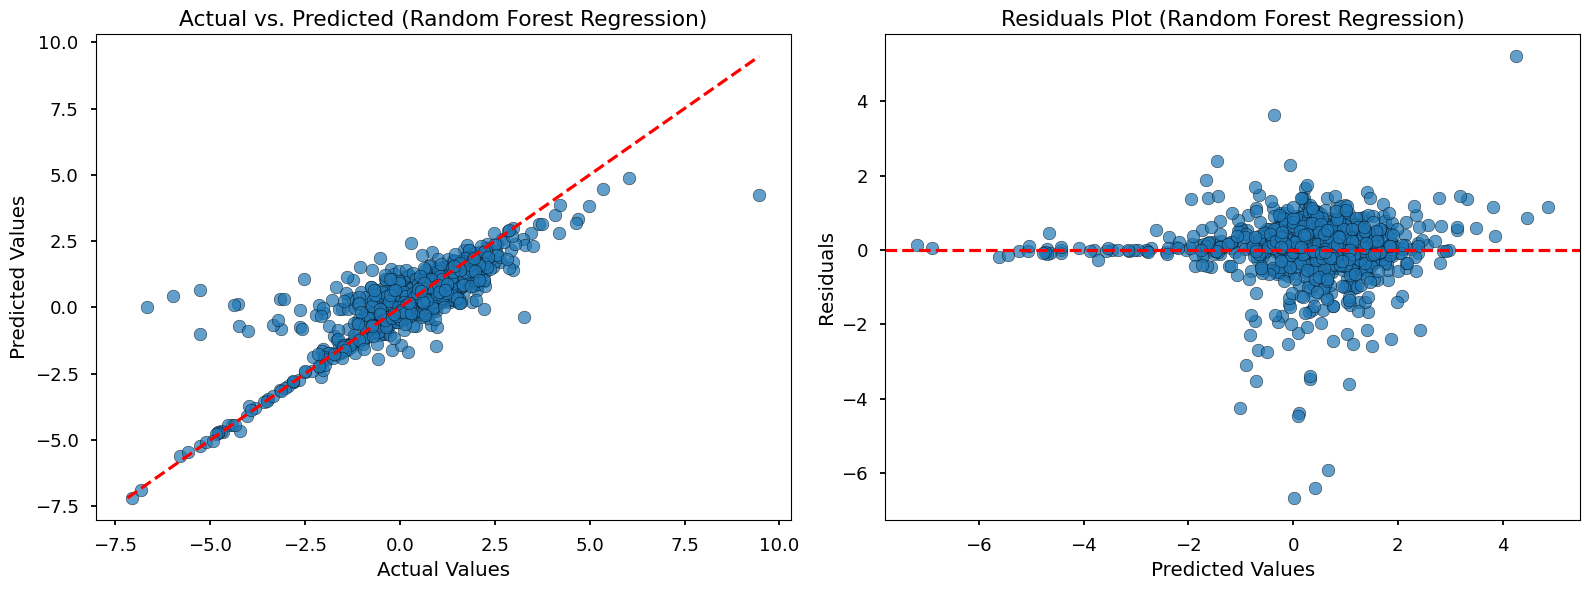

In [247]:
y_pred_reg = rf_reg.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs. Predicted scatter plot on the first subplot
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.7, edgecolor='k')
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Actual vs. Predicted (Random Forest Regression)")
min_val = min(min(y_test_reg), min(y_pred_reg))
max_val = max(max(y_test_reg), max(y_pred_reg))
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

# Residual plot on the second subplot
residuals = y_test_reg - y_pred_reg
axes[1].scatter(y_pred_reg, residuals, alpha=0.7, edgecolor='k')
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals Plot (Random Forest Regression)")
axes[1].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()


#### Boosting

In [248]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    num_infs = np.isinf(df[col]).sum()
    if num_infs > 0:
        print(f"Column '{col}' has {num_infs} infinite values.")

##### Impute the missing values

In [249]:
from sklearn.impute import SimpleImputer, KNNImputer
cols_to_impute = [
    'director_1_cc_ratio_log',
    'director_1_budget_efficiency_log',
    'actor_1_cc_ratio_log',
    'actor_1_budget_efficiency_log'
]

knn_imputer = KNNImputer(n_neighbors=5)
df[cols_to_impute] = knn_imputer.fit_transform(df[cols_to_impute])


Training GB regression model...
GB Regression - RMSE: 0.8937, R²: 0.7061, MAE: 0.5644
Training XGB regression model...
XGB Regression - RMSE: 0.8976, R²: 0.7035, MAE: 0.5688
Training LightGBM regression model...
LightGBM Regression - RMSE: 0.8857, R²: 0.7114, MAE: 0.5628
Training CatBoost regression model...
CatBoost Regression - RMSE: 0.8743, R²: 0.7187, MAE: 0.5555


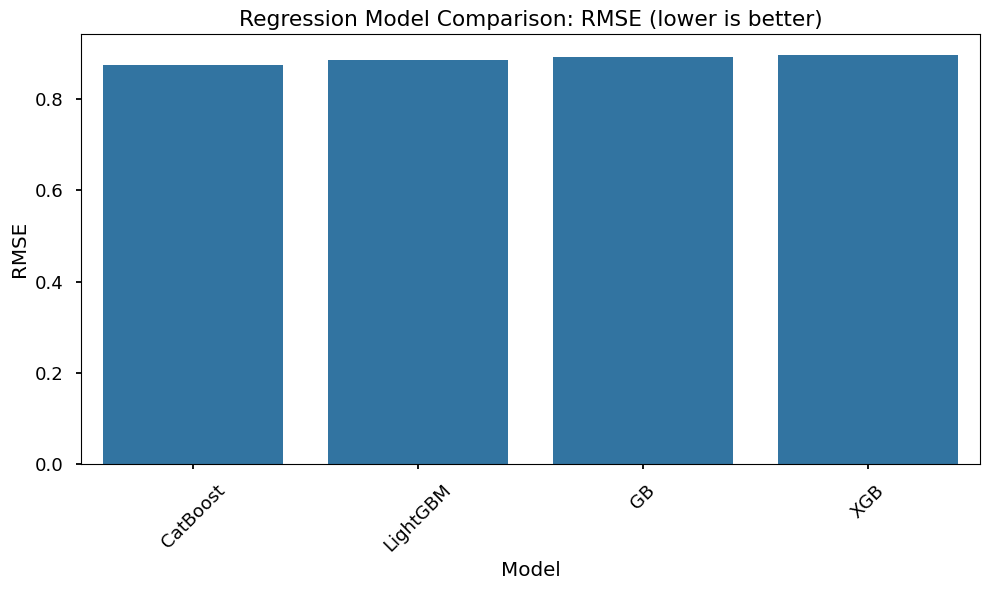

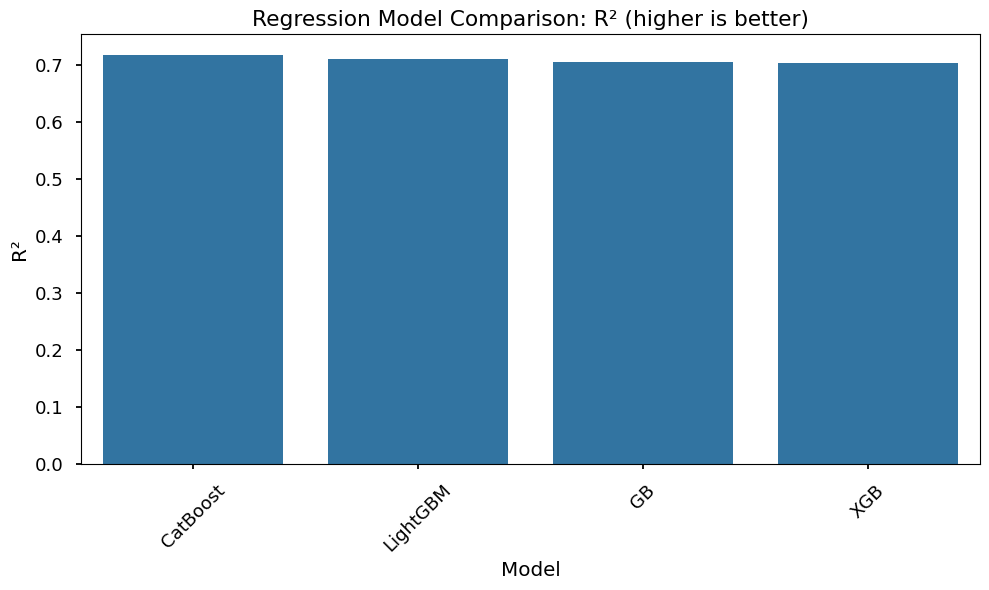

In [256]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns


regression_models = {}

regression_models['GB'] = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=0.8,
    random_state=42
)

regression_models['XGB'] = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

regression_models['LightGBM'] = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    use_missing=True  # Not needed when there are no missing values, but harmless here.
)

regression_models['CatBoost'] = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=5,
    loss_function='RMSE',
    random_seed=42,
    verbose=0,
    nan_mode='Min'  # Not required when no missing values exist.
)

# Train and evaluate all regression models
regression_results = []
for name, model in regression_models.items():
    print(f"Training {name} regression model...")
    
    # Fit model on training data
    model.fit(X_train, y_train_reg)
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    r2 = r2_score(y_test_reg, y_pred)
    mae = mean_absolute_error(y_test_reg, y_pred)
    
    metrics_str = f"RMSE: {rmse:.4f}, R²: {r2:.4f}, MAE: {mae:.4f}"
    print(f"{name} Regression - {metrics_str}")
    
    regression_results.append({
        'Model': name,
        'RMSE': rmse,
        'R²': r2,
        'MAE': mae
    })

# Create a DataFrame of results and visualize metrics
results_df = pd.DataFrame(regression_results).sort_values('RMSE')

# Visualize RMSE (lower is better)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=results_df)
plt.title('Regression Model Comparison: RMSE (lower is better)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualize R² (higher is better)
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R²', data=results_df)
plt.title('Regression Model Comparison: R² (higher is better)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Training quantile regression models...

Model Evaluation:
RMSE (median model): 0.9114
R² score (median model): 0.6944

Quantile Loss Evaluation:
Lower quantile (10%) loss: 0.1815
Median quantile (50%) loss: 0.2650
Upper quantile (90%) loss: 0.1098

80% prediction interval coverage: 73.80%
Expected coverage: 80.00%
Coverage difference: -6.20 percentage points


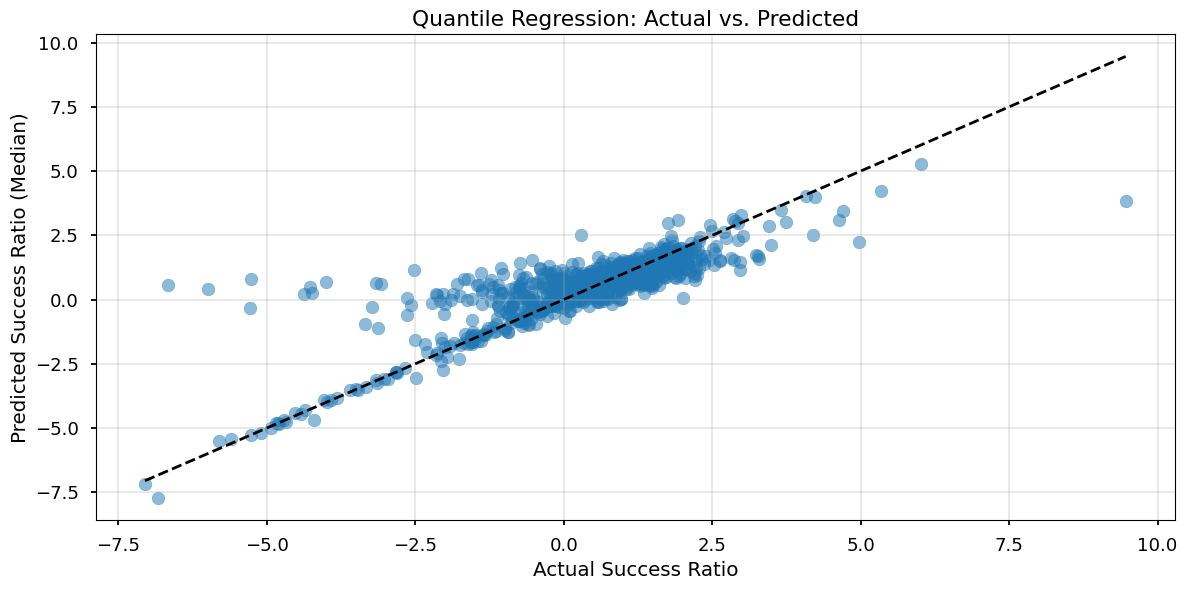

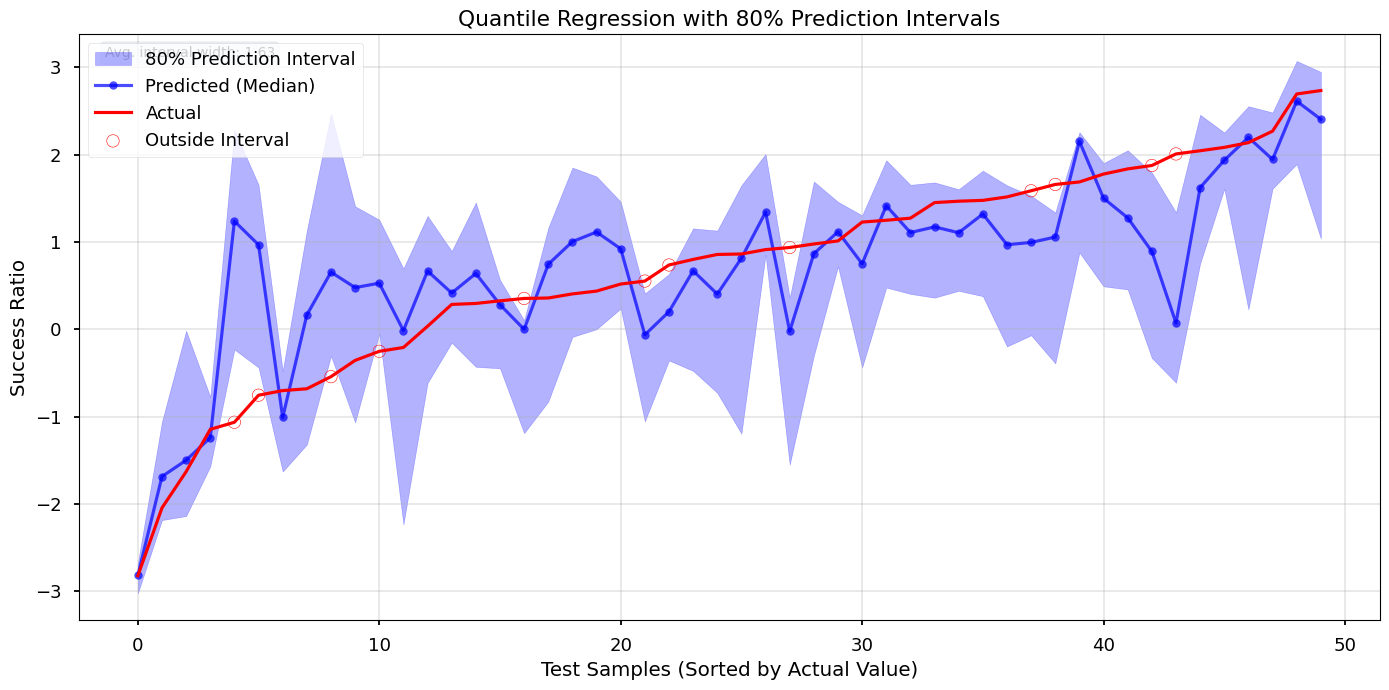

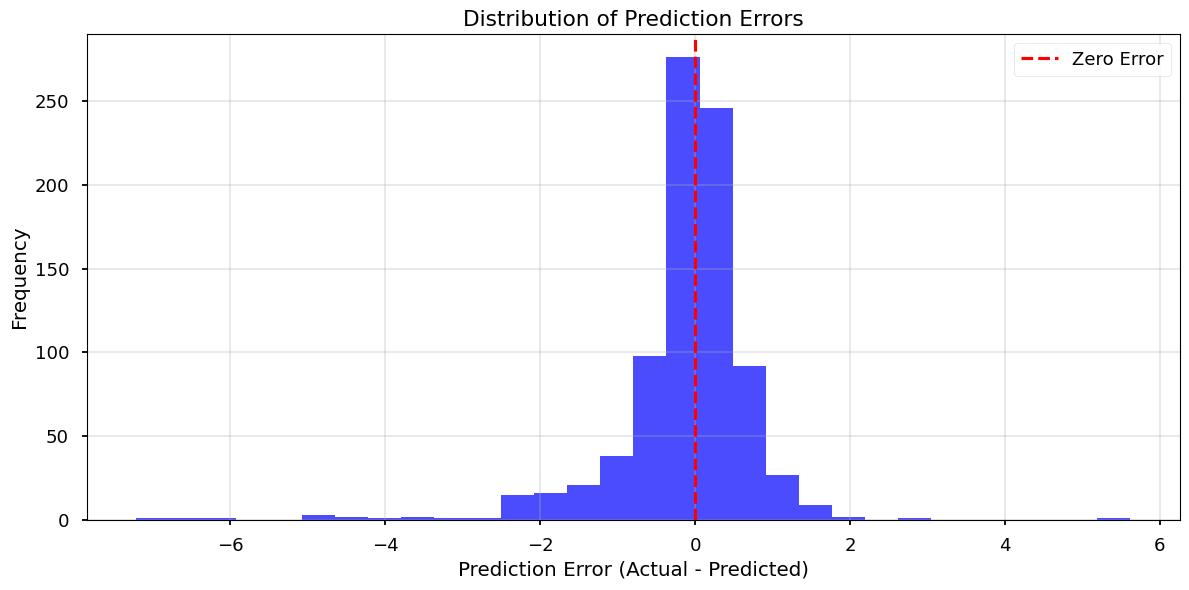

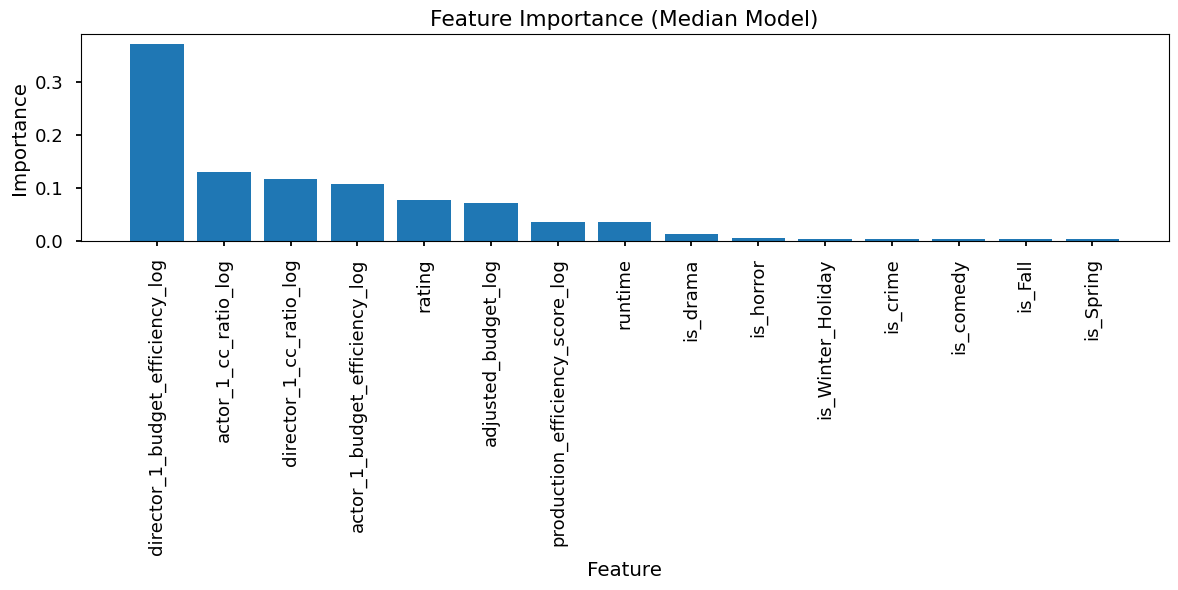

In [251]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define quantile loss function for evaluation
def quantile_loss(y_true, y_pred, quantile):
    """
    Calculate the quantile loss (pinball loss) for a specific quantile.
    
    Parameters:
    -----------
    y_true : array-like
        Actual target values
    y_pred : array-like
        Predicted values at the specified quantile
    quantile : float
        Quantile level (between 0 and 1)
    
    Returns:
    --------
    float
        Average quantile loss
    """
    error = y_true - y_pred
    return np.mean(np.maximum(quantile * error, (quantile-1) * error))

# Train three quantile regression models for lower bound, median, and upper bound
print("Training quantile regression models...")

# Upper bound (90th percentile)
quantile_gbr_upper = GradientBoostingRegressor(
    loss='quantile', alpha=0.9,  # 90th percentile
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# Median (50th percentile)
quantile_gbr_median = GradientBoostingRegressor(
    loss='quantile', alpha=0.5,  # median
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# Lower bound (10th percentile)
quantile_gbr_lower = GradientBoostingRegressor(
    loss='quantile', alpha=0.1,  # 10th percentile
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

# Train all three models
quantile_gbr_upper.fit(X_train, y_train_reg)
quantile_gbr_median.fit(X_train, y_train_reg)
quantile_gbr_lower.fit(X_train, y_train_reg)

# Generate predictions
y_pred_upper = quantile_gbr_upper.predict(X_test)
y_pred_median = quantile_gbr_median.predict(X_test)
y_pred_lower = quantile_gbr_lower.predict(X_test)

# Enforce proper quantile ordering (handling potential quantile crossing)
for i in range(len(y_pred_median)):
    y_pred_lower[i] = min(y_pred_lower[i], y_pred_median[i])
    y_pred_upper[i] = max(y_pred_upper[i], y_pred_median[i])

# Evaluate models
print("\nModel Evaluation:")
print(f"RMSE (median model): {np.sqrt(mean_squared_error(y_test_reg, y_pred_median)):.4f}")
print(f"R² score (median model): {r2_score(y_test_reg, y_pred_median):.4f}")

# Calculate quantile loss for each model
lower_loss = quantile_loss(y_test_reg, y_pred_lower, 0.1)
median_loss = quantile_loss(y_test_reg, y_pred_median, 0.5)
upper_loss = quantile_loss(y_test_reg, y_pred_upper, 0.9)

print(f"\nQuantile Loss Evaluation:")
print(f"Lower quantile (10%) loss: {lower_loss:.4f}")
print(f"Median quantile (50%) loss: {median_loss:.4f}")
print(f"Upper quantile (90%) loss: {upper_loss:.4f}")

# Calculate prediction interval coverage (should be around 80% for a 10%-90% interval)
coverage = np.mean((y_test_reg >= y_pred_lower) & (y_test_reg <= y_pred_upper))
print(f"\n80% prediction interval coverage: {coverage:.2%}")
print(f"Expected coverage: 80.00%")
print(f"Coverage difference: {(coverage - 0.8) * 100:.2f} percentage points")

# Visualization 1: Scatter plot of actual vs. predicted median values
plt.figure(figsize=(12, 6))
plt.scatter(y_test_reg, y_pred_median, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'k--', lw=2)
plt.xlabel('Actual Success Ratio')
plt.ylabel('Predicted Success Ratio (Median)')
plt.title('Quantile Regression: Actual vs. Predicted')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 2: Prediction intervals for a subset of samples
# Choose a subset of points to avoid cluttering
subset_size = min(50, len(y_test_reg))
subset_idx = np.random.choice(len(y_test_reg), subset_size, replace=False)

# Sort by actual values for better visualization
sorted_indices = np.argsort(y_test_reg.iloc[subset_idx])
x_indices = np.arange(len(sorted_indices))

actual_values = y_test_reg.iloc[subset_idx].values[sorted_indices]
median_pred = y_pred_median[subset_idx][sorted_indices]
lower_pred = y_pred_lower[subset_idx][sorted_indices]
upper_pred = y_pred_upper[subset_idx][sorted_indices]

plt.figure(figsize=(14, 7))

# Plot prediction intervals
plt.fill_between(x_indices, lower_pred, upper_pred, 
                 alpha=0.3, color='blue', label='80% Prediction Interval')

# Plot median predictions
plt.plot(x_indices, median_pred, 'bo-', ms=6, alpha=0.7, label='Predicted (Median)')

# Plot actual values
plt.plot(x_indices, actual_values, 'rx-', ms=8, label='Actual')

# Calculate and display the interval width for each point
interval_widths = upper_pred - lower_pred
mean_width = np.mean(interval_widths)
plt.text(0.02, 0.98, f'Avg. interval width: {mean_width:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))

# Calculate and highlight points outside the prediction interval
outside_interval = ~((actual_values >= lower_pred) & (actual_values <= upper_pred))
if np.any(outside_interval):
    plt.scatter(x_indices[outside_interval], 
                actual_values[outside_interval], 
                s=80, facecolors='none', edgecolors='red', 
                label='Outside Interval')

plt.title('Quantile Regression with 80% Prediction Intervals')
plt.xlabel('Test Samples (Sorted by Actual Value)')
plt.ylabel('Success Ratio')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 3: Prediction error distribution
plt.figure(figsize=(12, 6))
errors = y_test_reg - y_pred_median
plt.hist(errors, bins=30, alpha=0.7, color='blue')
plt.axvline(x=0, color='r', linestyle='--', label='Zero Error')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 4: Feature importance (optional if feature importance is relevant)
if hasattr(quantile_gbr_median, 'feature_importances_'):
    plt.figure(figsize=(12, 6))
    # Assuming X_train is a DataFrame with named columns
    if hasattr(X_train, 'columns'):
        feature_names = X_train.columns
        importance = quantile_gbr_median.feature_importances_
        indices = np.argsort(importance)[::-1]
        
        # Plot top 15 features or all if fewer than 15
        n_features = min(15, len(feature_names))
        plt.bar(range(n_features), importance[indices[:n_features]])
        plt.xticks(range(n_features), [feature_names[i] for i in indices[:n_features]], rotation=90)
        plt.xlabel('Feature')
        plt.ylabel('Importance')
        plt.title('Feature Importance (Median Model)')
        plt.tight_layout()
        plt.show()

Starting hyperparameter optimization...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 500, 'subsample': 0.8}
Calculating feature importance...
Creating polynomial features...
Training quantile models in parallel...
Generating predictions...
Processing results...
Evaluating models...
RMSE: 0.6714
R²: 0.8341
Lower quantile loss: 0.1345
Median quantile loss: 0.2196
Upper quantile loss: 0.0861
80% prediction interval coverage: 82.34%
Creating visualization...


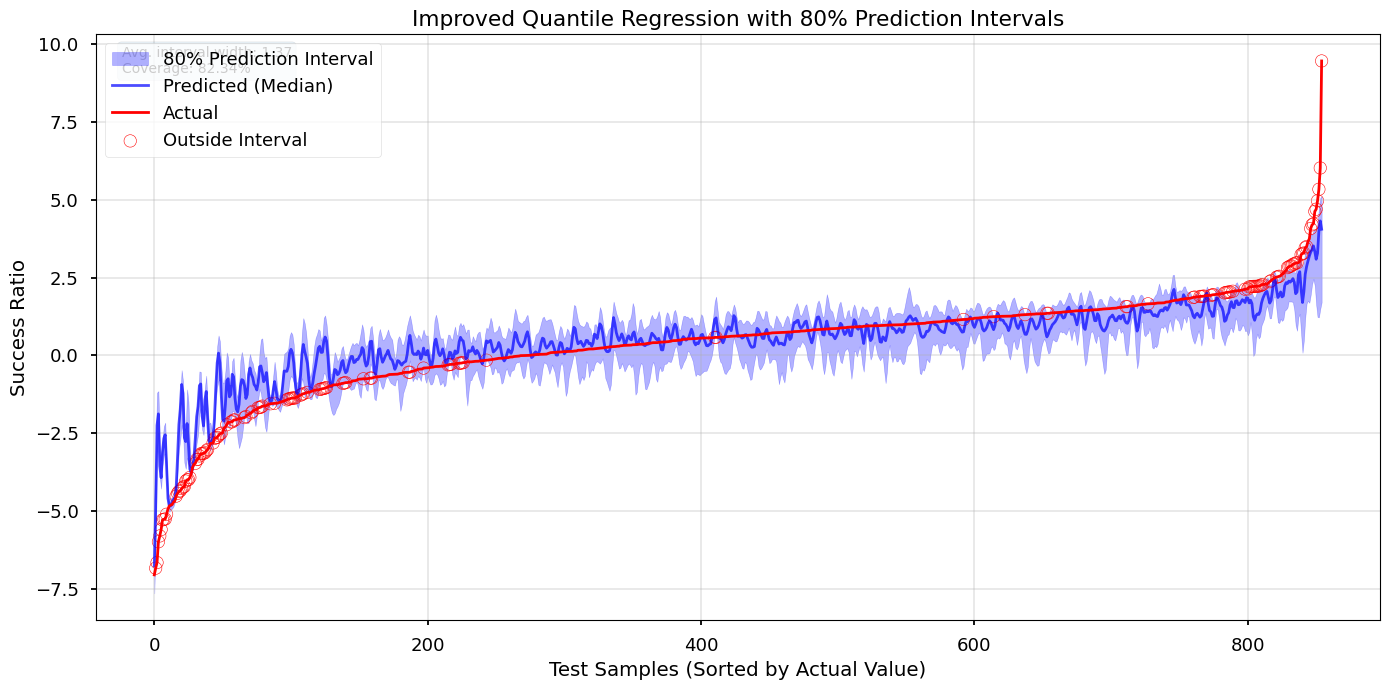

In [254]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.preprocessing import PolynomialFeatures
from scipy.ndimage import gaussian_filter1d
from joblib import Parallel, delayed, parallel_backend

# Define the quantile loss function
def quantile_loss(y_true, y_pred, quantile):
    error = y_true - y_pred
    return np.mean(np.maximum(quantile * error, (quantile-1) * error))

def quantile_loss_scorer(quantile):
    def loss(y_true, y_pred):
        return quantile_loss(y_true, y_pred, quantile)
    return make_scorer(loss, greater_is_better=False)

# 1. Reduced parameter grid for faster execution
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'min_samples_leaf': [1, 5],
    'subsample': [0.8]
}

# Create base model
median_gbr = GradientBoostingRegressor(loss='quantile', alpha=0.5, random_state=42)

# 2. Optimize GridSearchCV with parallel backend
print("Starting hyperparameter optimization...")
with parallel_backend('loky', n_jobs=20):
    grid_search = GridSearchCV(
        median_gbr, param_grid, cv=5, 
        scoring=quantile_loss_scorer(0.5),
        verbose=2, n_jobs=20,
        pre_dispatch='2*n_jobs'
    )
    grid_search.fit(X_train, y_train_reg)

best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# 3. Parallel feature importance calculation
print("Calculating feature importance...")
def get_feature_importance(X, y):
    model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)
    return model.feature_importances_

with parallel_backend('loky', n_jobs=20):
    feature_importances = get_feature_importance(X_train, y_train_reg)

# 4. Optimize feature engineering
important_indices = np.argsort(feature_importances)[-5:]
X_train_important = X_train.iloc[:, important_indices]
X_test_important = X_test.iloc[:, important_indices]

print("Creating polynomial features...")
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_poly = poly.fit_transform(X_train_important)
X_test_poly = poly.transform(X_test_important)

# Combine with original features
X_train_enhanced = np.hstack([X_train, X_train_poly])
X_test_enhanced = np.hstack([X_test, X_test_poly])

# 5. Train models in parallel
print("Training quantile models in parallel...")
def train_quantile_model(alpha, X_train, y_train, params):
    model = GradientBoostingRegressor(
        loss='quantile', alpha=alpha,
        **params,
        random_state=42
    )
    model.fit(X_train, y_train)
    return model, alpha

alphas = [0.1, 0.5, 0.9]
results = Parallel(n_jobs=3)(
    delayed(train_quantile_model)(alpha, X_train_enhanced, y_train_reg, best_params)
    for alpha in alphas
)

# Collect results
models = {alpha: model for model, alpha in results}
quantile_gbr_lower = models[0.1]
quantile_gbr_median = models[0.5]
quantile_gbr_upper = models[0.9]

# 6. Generate predictions in parallel
print("Generating predictions...")
def predict_model(model, X):
    return model.predict(X)

predictions = Parallel(n_jobs=3)(
    delayed(predict_model)(models[alpha], X_test_enhanced) 
    for alpha in alphas
)

y_pred_lower, y_pred_median, y_pred_upper = predictions

# 7. Process results
print("Processing results...")
# Ensure proper quantile ordering
for i in range(len(y_pred_median)):
    y_pred_lower[i] = min(y_pred_lower[i], y_pred_median[i])
    y_pred_upper[i] = max(y_pred_upper[i], y_pred_median[i])

# Sort predictions by actual values
sorted_idx = np.argsort(y_test_reg)
y_pred_lower_sorted = y_pred_lower[sorted_idx]
y_pred_median_sorted = y_pred_median[sorted_idx]
y_pred_upper_sorted = y_pred_upper[sorted_idx]

# Apply Gaussian smoothing
smoothing_sigma = 1.0
y_pred_lower_smooth = gaussian_filter1d(y_pred_lower_sorted, sigma=smoothing_sigma)
y_pred_median_smooth = gaussian_filter1d(y_pred_median_sorted, sigma=smoothing_sigma)
y_pred_upper_smooth = gaussian_filter1d(y_pred_upper_sorted, sigma=smoothing_sigma)

# 8. Evaluate and visualize
print("Evaluating models...")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg.iloc[sorted_idx], y_pred_median_smooth)):.4f}")
print(f"R²: {r2_score(y_test_reg.iloc[sorted_idx], y_pred_median_smooth):.4f}")

# Quantile losses
lower_loss = quantile_loss(y_test_reg.iloc[sorted_idx], y_pred_lower_smooth, 0.1)
median_loss = quantile_loss(y_test_reg.iloc[sorted_idx], y_pred_median_smooth, 0.5)
upper_loss = quantile_loss(y_test_reg.iloc[sorted_idx], y_pred_upper_smooth, 0.9)
print(f"Lower quantile loss: {lower_loss:.4f}")
print(f"Median quantile loss: {median_loss:.4f}")
print(f"Upper quantile loss: {upper_loss:.4f}")

# Calculate coverage
coverage = np.mean((y_test_reg.iloc[sorted_idx] >= y_pred_lower_smooth) & 
                  (y_test_reg.iloc[sorted_idx] <= y_pred_upper_smooth))
print(f"80% prediction interval coverage: {coverage:.2%}")

# Create visualization
print("Creating visualization...")
plt.figure(figsize=(14, 7))
plt.fill_between(range(len(sorted_idx)), y_pred_lower_smooth, y_pred_upper_smooth, 
                alpha=0.3, color='blue', label='80% Prediction Interval')
plt.plot(range(len(sorted_idx)), y_pred_median_smooth, 'b-', lw=2, 
         alpha=0.7, label='Predicted (Median)')
plt.plot(range(len(sorted_idx)), y_test_reg.iloc[sorted_idx], 'r-', lw=2, 
         label='Actual')

# Highlight points outside interval
outside_interval = ~((y_test_reg.iloc[sorted_idx] >= y_pred_lower_smooth) & 
                    (y_test_reg.iloc[sorted_idx] <= y_pred_upper_smooth))
if np.any(outside_interval):
    plt.scatter(np.arange(len(sorted_idx))[outside_interval], 
                y_test_reg.iloc[sorted_idx].values[outside_interval], 
                s=80, facecolors='none', edgecolors='red', 
                label='Outside Interval')

# Add interval width information
interval_widths = y_pred_upper_smooth - y_pred_lower_smooth
mean_width = np.mean(interval_widths)
plt.text(0.02, 0.98, f'Avg. interval width: {mean_width:.2f}\nCoverage: {coverage:.2%}', 
         transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))

plt.title('Improved Quantile Regression with 80% Prediction Intervals')
plt.xlabel('Test Samples (Sorted by Actual Value)')
plt.ylabel('Success Ratio')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Training 10 bootstrap ensembles using 20 cores...


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:  1.4min remaining:  5.5min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  1.4min finished


Successfully trained 10 models for each quantile
Generating ensemble predictions...
Applying smoothing and generating visualizations...
Mean Squared Error (MSE): 0.4562


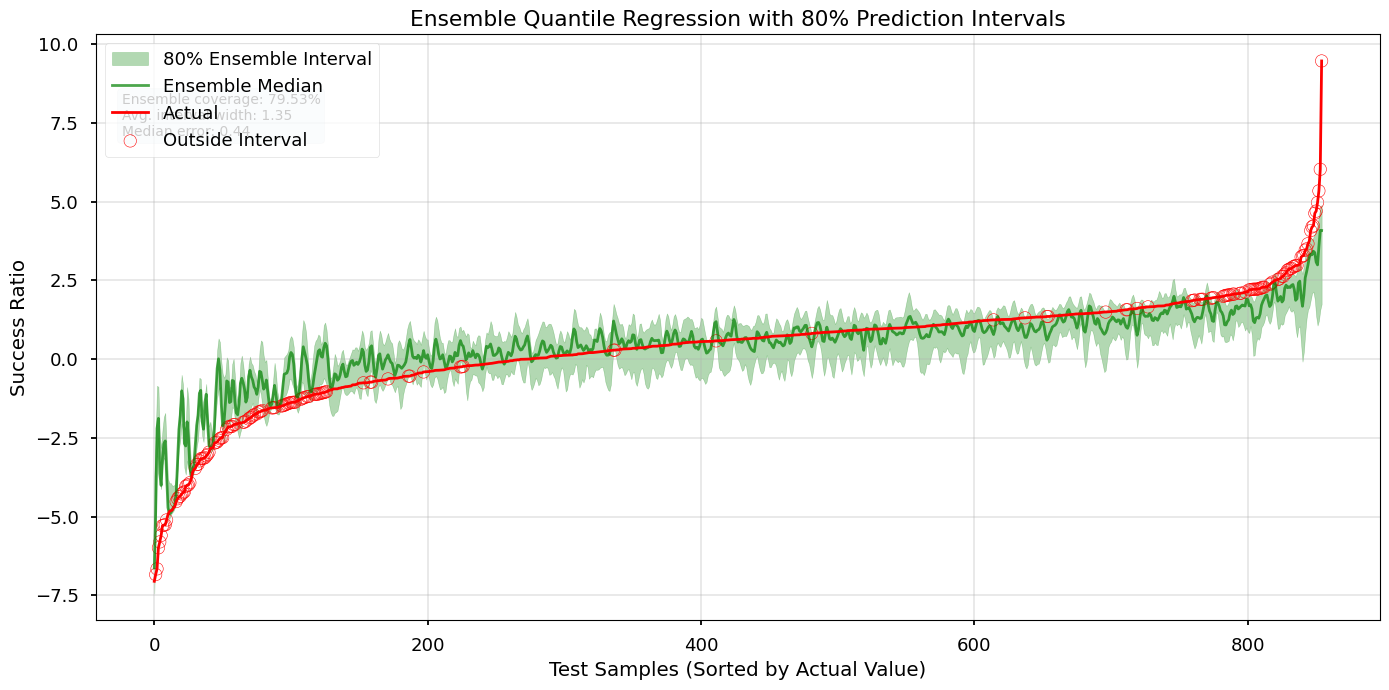

Done! Ensemble coverage: 79.53%


In [260]:
from joblib import Parallel, delayed, parallel_backend
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Parallel bootstrap model training function
def train_bootstrap_models(i, X_train_enhanced, y_train_reg, best_params):
    # Create bootstrap sample
    np.random.seed(i)  # Ensure reproducibility with different seed per bootstrap
    bootstrap_idx = np.random.choice(len(X_train_enhanced), len(X_train_enhanced), replace=True)
    X_boot = X_train_enhanced[bootstrap_idx]
    y_boot = y_train_reg.iloc[bootstrap_idx]
    
    # Train all three quantile models for this bootstrap
    models = {}
    for alpha in [0.1, 0.5, 0.9]:
        model = GradientBoostingRegressor(
            loss='quantile', 
            alpha=alpha, 
            **best_params, 
            random_state=i
        )
        model.fit(X_boot, y_boot)
        models[alpha] = model
    
    return models

# Number of bootstrap samples
n_bootstrap = 10
print(f"Training {n_bootstrap} bootstrap ensembles using 20 cores...")

# Train all bootstrap models in parallel
with parallel_backend('loky', n_jobs=20):
    all_bootstrap_models = Parallel(n_jobs=min(n_bootstrap, 20), verbose=1)(
        delayed(train_bootstrap_models)(i, X_train_enhanced, y_train_reg, best_params)
        for i in range(n_bootstrap)
    )

# Reorganize models by quantile
bootstrap_models = {alpha: [] for alpha in [0.1, 0.5, 0.9]}
for models in all_bootstrap_models:
    for alpha, model in models.items():
        bootstrap_models[alpha].append(model)

print(f"Successfully trained {len(bootstrap_models[0.1])} models for each quantile")

# Parallel prediction function for all models in an ensemble
def predict_ensemble(models, X, chunk_start=0, chunk_size=None):
    # Get the relevant subset of X if chunking is used
    X_chunk = X[chunk_start:chunk_start+chunk_size] if chunk_size else X
    
    # Make predictions for each model in the ensemble
    predictions = np.array([model.predict(X_chunk) for model in models])
    
    # Return median of predictions
    return np.median(predictions, axis=0)

# Determine if we need to chunk predictions for very large test sets
chunk_size = None
if X_test_enhanced.shape[0] > 10000:
    # For very large test sets, process in chunks to avoid memory issues
    chunk_size = 2000

# Process predictions in parallel across quantiles
print("Generating ensemble predictions...")
if chunk_size:
    # Process in chunks for large datasets
    chunks = [(i, min(chunk_size, X_test_enhanced.shape[0]-i)) 
              for i in range(0, X_test_enhanced.shape[0], chunk_size)]
    
    # Process each quantile model ensemble in parallel
    with parallel_backend('loky', n_jobs=3):
        ensemble_preds = Parallel(n_jobs=3)(
            delayed(lambda alpha: np.concatenate([
                predict_ensemble(bootstrap_models[alpha], X_test_enhanced, start, size)
                for start, size in chunks
            ]))(alpha)
            for alpha in [0.1, 0.5, 0.9]
        )
else:
    # Process each quantile model ensemble in parallel
    with parallel_backend('loky', n_jobs=3):
        ensemble_preds = Parallel(n_jobs=3)(
            delayed(predict_ensemble)(bootstrap_models[alpha], X_test_enhanced)
            for alpha in [0.1, 0.5, 0.9]
        )

# Unpack predictions
y_pred_lower_ensemble, y_pred_median_ensemble, y_pred_upper_ensemble = ensemble_preds

# Sort predictions by actual values for visualization
sorted_idx = np.argsort(y_test_reg)
y_pred_lower_ensemble_sorted = y_pred_lower_ensemble[sorted_idx]
y_pred_median_ensemble_sorted = y_pred_median_ensemble[sorted_idx]
y_pred_upper_ensemble_sorted = y_pred_upper_ensemble[sorted_idx]

# Apply Gaussian smoothing to reduce volatility
print("Applying smoothing and generating visualizations...")
smoothing_sigma = 1.0
y_pred_lower_ensemble_smooth = gaussian_filter1d(y_pred_lower_ensemble_sorted, sigma=smoothing_sigma)
y_pred_median_ensemble_smooth = gaussian_filter1d(y_pred_median_ensemble_sorted, sigma=smoothing_sigma)
y_pred_upper_ensemble_smooth = gaussian_filter1d(y_pred_upper_ensemble_sorted, sigma=smoothing_sigma)

from sklearn.metrics import mean_squared_error
mse_value = mean_squared_error(y_test_reg.iloc[sorted_idx], y_pred_median_ensemble_smooth)
print(f"Mean Squared Error (MSE): {mse_value:.4f}")

# Calculate metrics in parallel
def calc_metrics(y_true, y_lower, y_median, y_upper):
    # Calculate coverage
    coverage = np.mean((y_true >= y_lower) & (y_true <= y_upper))
    
    # Calculate width
    mean_width = np.mean(y_upper - y_lower)
    
    # Calculate median error
    median_error = np.mean(np.abs(y_true - y_median))
    
    return coverage, mean_width, median_error

metrics = calc_metrics(
    y_test_reg.iloc[sorted_idx],
    y_pred_lower_ensemble_smooth,
    y_pred_median_ensemble_smooth,
    y_pred_upper_ensemble_smooth
)
ensemble_coverage, mean_width, median_error = metrics

# Visualize ensemble predictions
plt.figure(figsize=(14, 7))
plt.fill_between(range(len(sorted_idx)), 
                 y_pred_lower_ensemble_smooth, 
                 y_pred_upper_ensemble_smooth, 
                 alpha=0.3, color='green', label='80% Ensemble Interval')
plt.plot(range(len(sorted_idx)), y_pred_median_ensemble_smooth, 'g-', lw=2, 
         alpha=0.7, label='Ensemble Median')
plt.plot(range(len(sorted_idx)), y_test_reg.iloc[sorted_idx], 'r-', lw=2, 
         label='Actual')

# Highlight points outside interval
outside_interval = ~((y_test_reg.iloc[sorted_idx] >= y_pred_lower_ensemble_smooth) & 
                     (y_test_reg.iloc[sorted_idx] <= y_pred_upper_ensemble_smooth))
if np.any(outside_interval):
    plt.scatter(np.arange(len(sorted_idx))[outside_interval], 
                y_test_reg.iloc[sorted_idx].values[outside_interval], 
                s=80, facecolors='none', edgecolors='red', 
                label='Outside Interval')

# Add metric information to plot
plt.text(0.02, 0.90, 
         f'Ensemble coverage: {ensemble_coverage:.2%}\n'
         f'Avg. interval width: {mean_width:.2f}\n'
         f'Median error: {median_error:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='top', bbox=dict(boxstyle='round', alpha=0.1))

plt.title('Ensemble Quantile Regression with 80% Prediction Intervals')
plt.xlabel('Test Samples (Sorted by Actual Value)')
plt.ylabel('Success Ratio')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Done! Ensemble coverage: {ensemble_coverage:.2%}")

In [219]:
from sklearn.ensemble import StackingRegressor, StackingClassifier
from sklearn.linear_model import RidgeCV, LogisticRegressionCV

# Define base models for regression
base_regressors = [
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ('catboost', CatBoostRegressor(iterations=300, random_seed=42, verbose=0))
]

# Define base models for classification
base_classifiers = [
    ('rf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
    ('catboost', CatBoostClassifier(iterations=300, random_seed=42, verbose=0))
]

# Create stacked models
stacked_reg = StackingRegressor(
    estimators=base_regressors,
    final_estimator=RidgeCV(alphas=[0.1, 1.0, 10.0]),
    cv=5,
    n_jobs=-1
)

stacked_cls = StackingClassifier(
    estimators=base_classifiers,
    final_estimator=LogisticRegressionCV(cv=5, random_state=42, max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Fit stacked models
stacked_reg.fit(X_train, y_train_reg)
stacked_cls.fit(X_train, y_train_cls)

# Evaluate
y_pred_reg = stacked_reg.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
print(f"Stacked Ensemble Regression - RMSE: {rmse:.4f}, R²: {r2:.4f}")

y_pred_cls = stacked_cls.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred_cls)
print(f"Stacked Ensemble Classification - Accuracy: {accuracy:.4f}")
print(classification_report(y_test_cls, y_pred_cls))

Stacked Ensemble Regression - RMSE: 0.8955, R²: 0.7374
Stacked Ensemble Classification - Accuracy: 0.5825
                precision    recall  f1-score   support

       Average       0.43      0.50      0.47       171
   Blockbuster       0.72      0.68      0.70       171
          Flop       0.84      0.69      0.76       171
       Success       0.44      0.51      0.47       171
Underperformer       0.58      0.53      0.55       171

      accuracy                           0.58       855
     macro avg       0.60      0.58      0.59       855
  weighted avg       0.60      0.58      0.59       855

